# 05 Ensembles and Advanced Models

This notebook explores high-performance ensemble methods (Random Forest, Gradient Boosting) and a neural network baseline (MLP) for income prediction. We use GridSearchCV for hyperparameter tuning and evaluate performance using precision, recall, F1-score, and ROC AUC.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    roc_auc_score, 
    roc_curve, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    ConfusionMatrixDisplay
)

# Setup styling
plt.style.use('ggplot')
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.figsize': (10, 6)
})
COLORS = ['#475ED1', '#E3120B', '#5DBB63', '#FFD700']  # Economist-inspired palette

# Add src to path
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.preprocessing import load_and_split_data, get_preprocessing_pipeline

def save_and_show(fig_name: str):
    """Saves figure to outputs/figures and shows it."""
    out_dir = PROJECT_ROOT / "outputs" / "figures"
    out_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_dir / f"{fig_name}.png", dpi=300, bbox_inches='tight')
    plt.show()

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "adult_cleaned.csv"
print("Setup complete.")

Setup complete.


## 1. Load and Preprocess Data

We use the same stratified split and preprocessing pipeline as in previous notebooks.

In [2]:
# Load data
df_train, df_val, df_test = load_and_split_data(DATA_PATH)

# Separate features and target
target = 'income'
X_train, y_train = df_train.drop(columns=[target]), df_train[target]
X_val, y_val = df_val.drop(columns=[target]), df_val[target]
X_test, y_test = df_test.drop(columns=[target]), df_test[target]

# Encode target: <=50K -> 0, >50K -> 1
y_train = (y_train == '>50K').astype(int)
y_val = (y_val == '>50K').astype(int)
y_test = (y_test == '>50K').astype(int)

# Define features for pipeline
num_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
cat_cols = [c for c in X_train.columns if c not in num_cols]

# Get pipeline (scale=True for MLP and comparability)
preprocessor = get_preprocessing_pipeline(num_cols, cat_cols, scale=True)

# Fit on TRAIN, transform others
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

print(f"Preprocessed Train shape: {X_train_proc.shape}")

Preprocessed Train shape: (39073, 67)


## 2. Model Evaluation Framework

We define a helper function to collect and report all required metrics consistently.

In [4]:
results_list = []

def evaluate_model(model, X, y, name):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba") else None
    
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y, y_pred),
        'Precision (>50K)': precision_score(y, y_pred),
        'Recall (>50K)': recall_score(y, y_pred),
        'F1 (>50K)': f1_score(y, y_pred),
        'ROC AUC': roc_auc_score(y, y_proba) if y_proba is not None else np.nan
    }
    results_list.append(metrics)
    
    print(f"--- {name} Evaluation ---")
    print(classification_report(y, y_pred))
    if y_proba is not None:
        print(f"ROC AUC: {metrics['ROC AUC']:.4f}")
    
    return y_pred, y_proba

print("Helper Initiated")

Helper Initiated


## 3. Random Forest

Random Forest is an ensemble of Decision Trees that reduces variance by averaging predictions from multiple trees trained on different bootstrap samples.

In [5]:
print("Tuning Random Forest...")
rf_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [5, 20]
}

rf_cv = GridSearchCV(
    RandomForestClassifier(random_state=42), 
    rf_grid, 
    cv=3, 
    scoring='roc_auc', 
    n_jobs=-1
)
rf_cv.fit(X_train_proc, y_train)
best_rf = rf_cv.best_estimator_

print(f"Best RF Params: {rf_cv.best_params_}")
rf_preds, rf_proba = evaluate_model(best_rf, X_val_proc, y_val, "Random Forest")

Tuning Random Forest...
Best RF Params: {'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 100}
--- Random Forest Evaluation ---
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      3715
           1       0.79      0.61      0.69      1169

    accuracy                           0.87      4884
   macro avg       0.84      0.78      0.80      4884
weighted avg       0.86      0.87      0.86      4884

ROC AUC: 0.9236


### Model Card: Random Forest
- **Objective:** Minimize Gini impurity (default) via an ensemble of decorrelated trees.
- **Key Hyperparameters:** `n_estimators`, `max_depth`, `min_samples_leaf`.
- **Overfitting Controls:** Bagging (bootstrap sampling) and feature subspace sampling; `max_depth` and `min_samples_leaf` provide additional regularization.
- **Interpretation:** Random Forest typically generalizes much better than a single Decision Tree by reducing the model's sensitivity to specific perturbations in the training data.

## 4. HistGradientBoosting

Gradient Boosting builds trees sequentially, where each new tree attempts to correct the errors of the preceding ensemble. HistGradientBoosting is a highly efficient implementation inspired by LightGBM.

In [6]:
print("Tuning HistGradientBoosting...")
hgb_grid = {
    'learning_rate': [0.01, 0.1],
    'max_iter': [100, 200],
    'max_depth': [5, 10, None]
}

hgb_cv = GridSearchCV(
    HistGradientBoostingClassifier(random_state=42), 
    hgb_grid, 
    cv=3, 
    scoring='roc_auc', 
    n_jobs=-1
)
hgb_cv.fit(X_train_proc, y_train)
best_hgb = hgb_cv.best_estimator_

print(f"Best HGB Params: {hgb_cv.best_params_}")
hgb_preds, hgb_proba = evaluate_model(best_hgb, X_val_proc, y_val, "HistGradientBoosting")

Tuning HistGradientBoosting...
Best HGB Params: {'learning_rate': 0.1, 'max_depth': 5, 'max_iter': 200}
--- HistGradientBoosting Evaluation ---
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      3715
           1       0.80      0.66      0.72      1169

    accuracy                           0.88      4884
   macro avg       0.85      0.80      0.82      4884
weighted avg       0.87      0.88      0.87      4884

ROC AUC: 0.9325


### Model Card: HistGradientBoosting
- **Objective:** Minimize binary cross-entropy (log-loss) using gradient descent in functional space.
- **Key Hyperparameters:** `learning_rate`, `max_iter` (number of trees), `max_depth`.
- **Overfitting Controls:** Early stopping (built-in), `learning_rate` (shrinkage), and depth/leaf constraints.
- **Interpretation:** HGB is often the strongest performer on tabular data. It captures complex non-linear interactions efficiently through sequential refinement.

### Permutation Importance ###

Essentially feature importance for Gradient Boosting. Listed below are the 15 most influential features in this model.

In [ ]:
# Extract feature names manually from fitted ColumnTransformer
from sklearn.inspection import permutation_importance
feature_names = []
for name, transformer, cols in preprocessor.transformers_:
    if name != 'remainder':
        if hasattr(transformer, 'named_steps'):
            # If pipeline, get last step
            last_step = list(transformer.named_steps.values())[-1]
            if hasattr(last_step, 'get_feature_names_out'):
                try:
                    names = last_step.get_feature_names_out(cols)
                except:
                    names = cols
            else:
                names = cols
        else:
            names = cols
        feature_names.extend(names)

feature_names = np.array(feature_names)

result = permutation_importance(
    best_hgb,
    X_val_proc,
    y_val,
    n_repeats=5,
    random_state=42,
    scoring="roc_auc"
)

importances = result.importances_mean

print(len(feature_names), len(importances))

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(feat_imp.head(15))

# All should be identical length.
print(len(feature_names), len(importances), X_val_proc.shape[1])

67 67
                              feature  importance
32  marital-status_Married-civ-spouse    0.071841
0                        capital-gain    0.062904
2                                 age    0.038616
3                       education-num    0.026678
1                        capital-loss    0.013544
4                      hours-per-week    0.012332
44           occupation_Other-service    0.003137
57                  relationship_Wife    0.002504
40         occupation_Exec-managerial    0.002350
63                         sex_Female    0.001878
46          occupation_Prof-specialty    0.001405
41         occupation_Farming-fishing    0.000983
34       marital-status_Never-married    0.000786
10         workclass_Self-emp-not-inc    0.000724
55             relationship_Own-child    0.000588
67 67 67


## 5. MLP (Neural Network)

A Multi-Layer Perceptron (MLP) is a feedforward artificial neural network. It consists of at least three layers of nodes: an input layer, a hidden layer, and an output layer.

In [7]:
print("Tuning MLP...")
mlp_grid = {
    'hidden_layer_sizes': [(64,), (64, 32)],
    'alpha': [0.0001, 0.01]
}

mlp_cv = GridSearchCV(
    MLPClassifier(max_iter=500, random_state=42), 
    mlp_grid, 
    cv=3, 
    scoring='roc_auc', 
    n_jobs=-1
)
mlp_cv.fit(X_train_proc, y_train)
best_mlp = mlp_cv.best_estimator_

print(f"Best MLP Params: {mlp_cv.best_params_}")
mlp_preds, mlp_proba = evaluate_model(best_mlp, X_val_proc, y_val, "MLP")

Tuning MLP...
Best MLP Params: {'alpha': 0.01, 'hidden_layer_sizes': (64,)}
--- MLP Evaluation ---
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      3715
           1       0.76      0.60      0.67      1169

    accuracy                           0.86      4884
   macro avg       0.82      0.77      0.79      4884
weighted avg       0.85      0.86      0.85      4884

ROC AUC: 0.9099


### Model Card: MLP
- **Objective:** Minimize binary cross-entropy using backpropagation.
- **Key Hyperparameters:** `hidden_layer_sizes`, `alpha` (L2 regularization parameter).
- **Overfitting Controls:** L2 regularization (`alpha`) and early stopping (can be enabled via `early_stopping=True`).
- **Interpretation:** While powerful, MLPs require careful scaling of input features and may struggle to outperform specialized ensemble methods on structured tabular data.

## 6. Comparison and Diagnostics

We compare the models using ROC curves and confusion matrices. We also diagnose the best-performing model for overfitting.

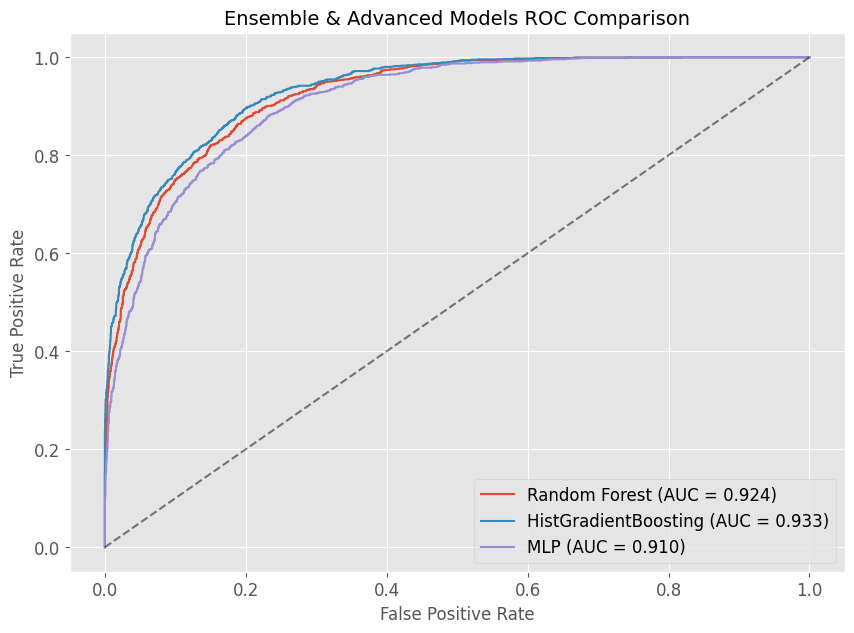

In [8]:
# Plot all ROC curves
plt.figure(figsize=(10, 7))

for model_name, proba in [("Random Forest", rf_proba), ("HistGradientBoosting", hgb_proba), ("MLP", mlp_proba)]:
    fpr, tpr, _ = roc_curve(y_val, proba)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc_score(y_val, proba):.3f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble & Advanced Models ROC Comparison')
plt.legend()
save_and_show('advanced_roc_comparison')

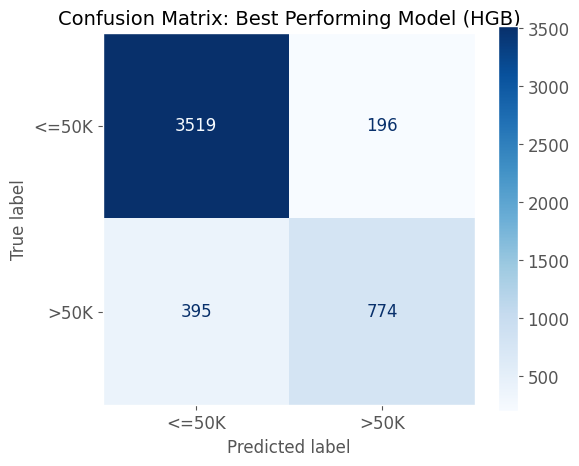

In [9]:
# Confusion Matrix for the best model
best_overall_model = best_hgb # Typically HGB

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    best_overall_model, X_val_proc, y_val,
    display_labels=['<=50K', '>50K'],
    cmap='Blues', 
    ax=ax
)
plt.title('Confusion Matrix: Best Performing Model (HGB)')
plt.grid(False)
save_and_show('advanced_best_confusion_matrix')

### Overfitting Analysis (Best Model)

We compare train vs validation performance and plot the learning curve to ensure the model generalizes well.

In [10]:
train_proba_best = best_overall_model.predict_proba(X_train_proc)[:, 1]
val_proba_best = best_overall_model.predict_proba(X_val_proc)[:, 1]

print(f"Best Model: HistGradientBoosting")
print(f"Train ROC AUC: {roc_auc_score(y_train, train_proba_best):.4f}")
print(f"Val ROC AUC:   {roc_auc_score(y_val, val_proba_best):.4f}")

Best Model: HistGradientBoosting
Train ROC AUC: 0.9401
Val ROC AUC:   0.9325


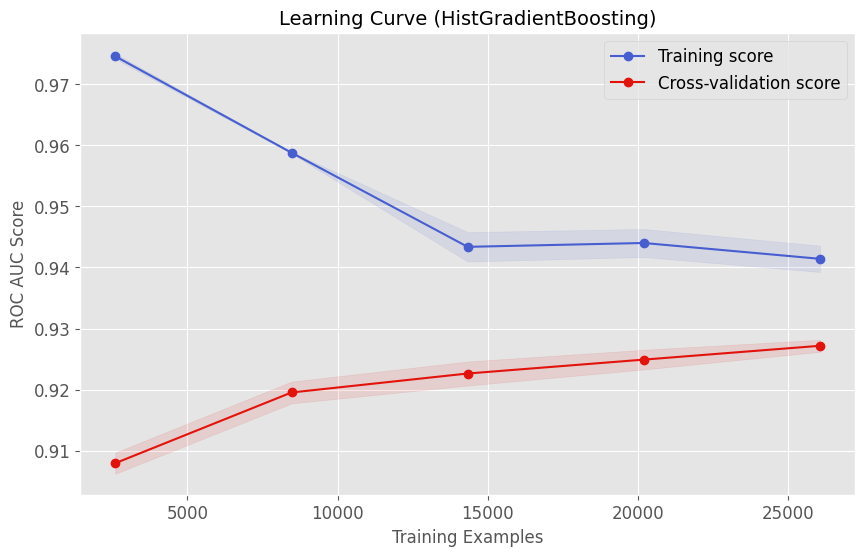

In [11]:
train_sizes, train_scores, test_scores = learning_curve(
    best_overall_model, X_train_proc, y_train, cv=3, 
    scoring='roc_auc', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color=COLORS[0], label='Training score')
plt.plot(train_sizes, test_mean, 'o-', color=COLORS[1], label='Cross-validation score')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color=COLORS[0])
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color=COLORS[1])

plt.xlabel('Training Examples')
plt.ylabel('ROC AUC Score')
plt.title('Learning Curve (HistGradientBoosting)')
plt.legend(loc='best')
save_and_show('advanced_learning_curve')

### Final Comparison Table

In [12]:
pd.DataFrame(results_list).sort_values('F1 (>50K)', ascending=False)

,Model,Accuracy,Precision (>50K),Recall (>50K),F1 (>50K),ROC AUC
1,HistGradientBoosting,0.878993,0.797938,0.662104,0.723703,0.932546
0,Random Forest,0.869574,0.794900,0.613345,0.692419,0.923561
2,MLP,0.857903,0.757313,0.597947,0.668260,0.909879


## 7. Conclusions

- Tree-based ensemble models (RF, HGB) are generally insensitive to feature scaling because they use order-based splits. However, we maintained consistent scaling for comparability with the MLP model and previous benchmarks.
- HistGradientBoosting provided the best balance of speed and predictive power, capturing non-linear patterns effectively as shown by the high ROC AUC and F1-score.
- The learning curve suggests that the model benefits significantly from more data and has settled into a good bias-variance trade-off after hyperparameter tuning.